**Installing dependencies**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from wordcloud import WordCloud

In [2]:
from google.colab import files
uploaded = files.upload()


Saving NLP_Law_Dataset.zip to NLP_Law_Dataset.zip


In [3]:
!pip install krippendorff

In [4]:
!pip install tensorflow

**Loading dataset**

In [5]:
y
!unzip /content/NLP_Law_Dataset.zip -d /content/NLP_Law


Archive:  /content/NLP_Law_Dataset.zip
replace /content/NLP_Law/absence-of-certain-changes-or-events.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/NLP_Law/absence-of-certain-changes-or-events.csv  
replace /content/NLP_Law/absence-of-certain-changes.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/NLP_Law/absence-of-certain-changes.csv  
replace /content/NLP_Law/acceleration.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/NLP_Law/acceleration.csv  
replace /content/NLP_Law/access-to-information.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/NLP_Law/access-to-information.csv  
replace /content/NLP_Law/access.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/NLP_Law/access.csv  
replace /content/NLP_Law/accounting-terms.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/NLP_Law/accounting-terms.csv  
replace /content/NLP_Law/additional-agreements.csv? [y]es, [n]o, [A]ll, [N]one,

In [6]:
!ls /content/NLP_Law


absence-of-certain-changes.csv
absence-of-certain-changes-or-events.csv
acceleration.csv
access.csv
access-to-information.csv
accounting-terms.csv
additional-agreements.csv
additional-documents.csv
adjustments.csv
affirmative-covenants.csv
agreement.csv
agreements.csv
amendment-and-waiver.csv
amendment.csv
amendments-and-waivers.csv
amendments.csv
amendments-etc.csv
amendments-waivers.csv
amendment-waiver.csv
applicable-law.csv
application-of-proceeds.csv
appointment.csv
approvals.csv
arbitration.csv
assignability.csv
assignment.csv
assignments.csv
attorneys-fees.csv
authority.csv
authorization.csv
auto_renewal.csv
background.csv
bank-accounts.csv
bankruptcy.csv
base-salary.csv
benefits.csv
bereavement-leave.csv
binding-effect.csv
bonus.csv
books-and-records.csv
brokerage.csv
brokers.csv
cancellation.csv
capitalization.csv
capitalized-terms.csv
captions.csv
cause.csv
certain-defined-terms.csv
certain-definitions.csv
certificates.csv
change-in-control.csv
change-of-control.csv
choice-of

In [7]:
sns.set(style="whitegrid", palette="pastel")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

data_path = "/content/NLP_Law"

In [8]:
files = [
    "acceleration.csv",
    "confidentiality.csv",
    "termination.csv",
    "payment.csv",
    "governing-law.csv",
    "indemnification.csv",
    "force-majeure.csv",
    "licenses.csv",
    "voting.csv",
    "litigation.csv",
    "waiver.csv",
    "vacation.csv",
    "security-deposit.csv",
    "bonus.csv",
    "rent.csv",
    "judgments.csv",
    "survival.csv",
    "non-discrimination.csv",
    "power-of-attorney.csv",
    "employee-benefits.csv"

]

In [9]:

datasets = {}
for file in files:
    name = file.replace(".csv", "").replace("-", "_")
    datasets[name] = pd.read_csv(os.path.join(data_path, file))

for name, df in datasets.items():
    print(f"{name}")
    print(df.head(), "\n")


acceleration
                                         clause_text   clause_type
0  Acceleration. On and at any time after the occ...  acceleration
1  Acceleration. (a) If an Event of Default with ...  acceleration
2  Acceleration. If an Event of Default (other th...  acceleration
3  Acceleration. If an Event of Default with resp...  acceleration
4  Acceleration. If any Default described in Sect...  acceleration 

confidentiality
                                         clause_text      clause_type
0  Confidentiality. The parties hereto agree that...  confidentiality
1  Confidentiality. The Parties acknowledge that ...  confidentiality
2  Confidentiality. (a) Subject to Section 7.15(c...  confidentiality
3  Confidentiality. The Executive recognizes and ...  confidentiality
4  Confidentiality. Subject to the duties of the ...  confidentiality 

termination
                                         clause_text  clause_type
0  Termination. This Agreement may be terminated ...  termination
1

**Visualising datasets**

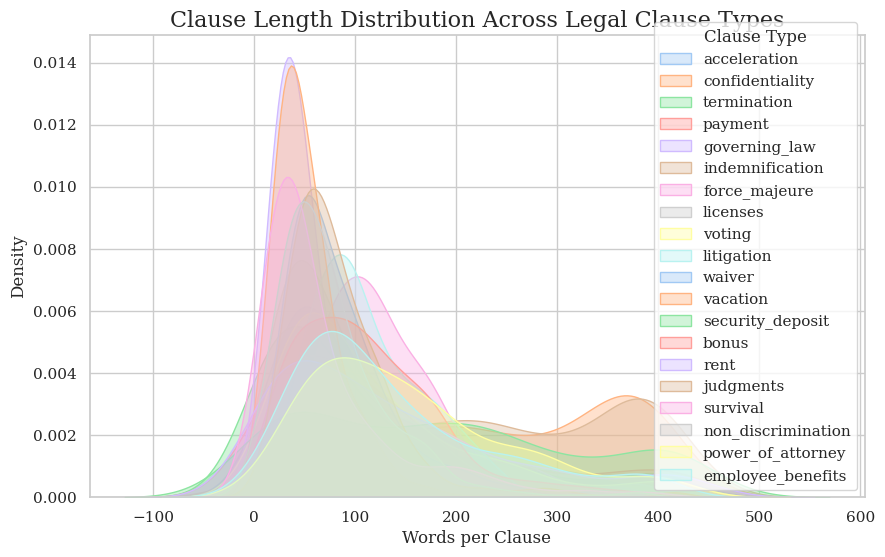

In [10]:
plt.figure(figsize=(10,6))
for name, df in datasets.items():
    df["clause_length"] = df["clause_text"].apply(lambda x: len(str(x).split()))
    sns.kdeplot(df["clause_length"], label=name, fill=True, alpha=0.4)
plt.title("Clause Length Distribution Across Legal Clause Types")
plt.xlabel("Words per Clause")
plt.ylabel("Density")
plt.legend(title="Clause Type")
plt.show()


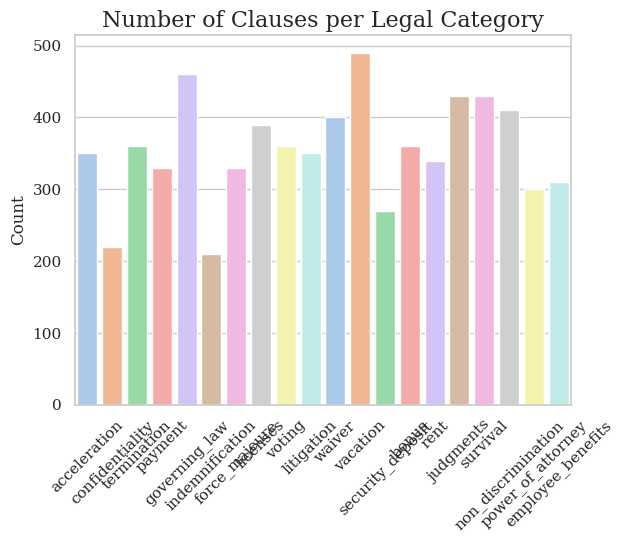

In [11]:
counts = {name: len(df) for name, df in datasets.items()}
sns.barplot(x=list(counts.keys()), y=list(counts.values()), hue=list(counts.keys()),
            palette="pastel", legend=False)
plt.title("Number of Clauses per Legal Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [12]:
colormaps = {
    "acceleration": "Blues",
    "confidentiality": "Greens",
    "termination": "Oranges",
    "payment": "Reds",
    "governing_law": "Purples",
    "indemnification": "pink_r",
    "force_majeure": "cool",
    "licenses": "Set3",
    "voting": "Pastel1",
    "litigation": "Pastel2",
    "waiver": "Wistia",
    "vacation": "spring",
    "security_deposit": "summer",
    "rent": "autumn",
    "judgments": "Pastel2_r",
    "survival": "Pastel1_r",
    "non_discrimination": "Pastel2_r",
    "power_of_attorney": "pink_r",
    "employee_benefits": "coolwarm"
}


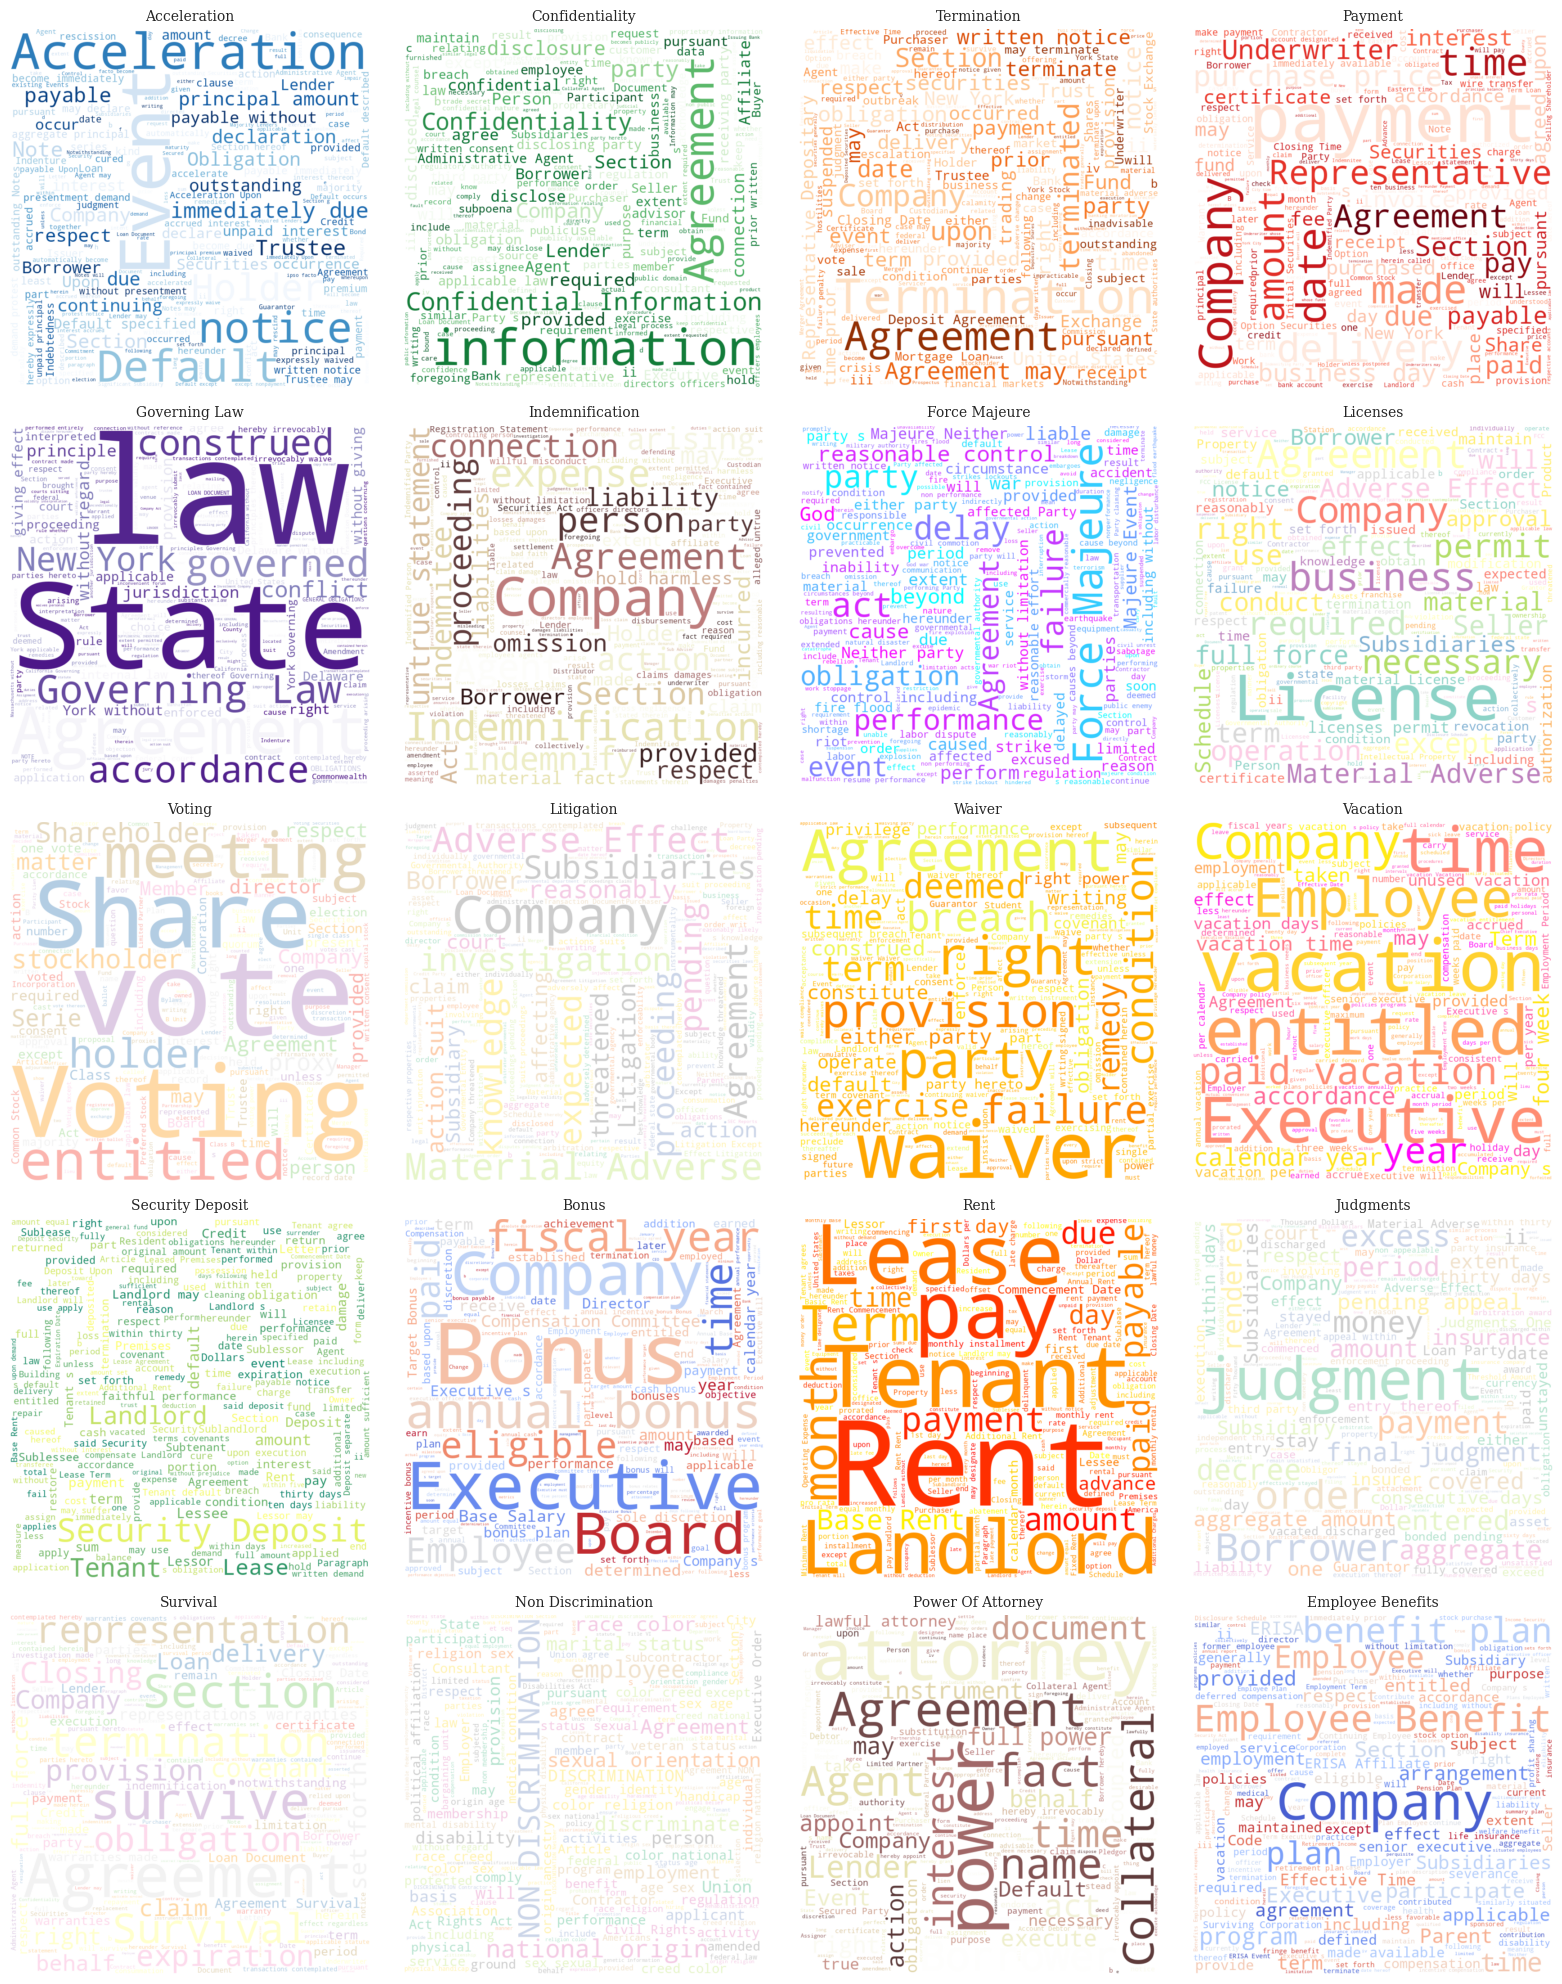

In [13]:
import math

n = len(datasets)
max_cols = 4
rows = math.ceil(n / max_cols)
cols = min(n, max_cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = axes.flatten()
for i, (name, df) in enumerate(datasets.items()):
    text = " ".join(str(t) for t in df["clause_text"])
    cmap = colormaps.get(name, "coolwarm")
    wc = WordCloud(width=800, height=800, background_color="white", colormap=cmap).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis("off")
    axes[i].set_title(name.replace("_"," ").title(), fontsize=10)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [14]:
all_clauses = []

for name, df in datasets.items():
    all_clauses.extend(df["clause_text"].astype(str).tolist())
total_clauses = len(all_clauses)
print(f"Total number of clauses across all datasets: {total_clauses}")


Total number of clauses across all datasets: 7100


**Examining dataset**

In [15]:
import pandas as pd

df_details = []

for name, df in datasets.items():
    num_clauses = df.shape[0]
    missing_values = df['clause_text'].isna().sum()
    avg_length = df['clause_text'].dropna().apply(lambda x: len(str(x).split())).mean()
    max_length = df['clause_text'].dropna().apply(lambda x: len(str(x).split())).max()
    min_length = df['clause_text'].dropna().apply(lambda x: len(str(x).split())).min()

    df_details.append({
        'clause_category': name,
        'num_clauses': num_clauses,
        'missing_values': missing_values,
        'avg_length_words': round(avg_length, 2),
        'max_length_words': max_length,
        'min_length_words': min_length
    })
summary = pd.DataFrame(df_details)



In [16]:
summary

,clause_category,num_clauses,missing_values,avg_length_words,max_length_words,min_length_words
0,acceleration,350,0,119.86,437,4
1,confidentiality,220,0,242.92,417,7
2,termination,360,0,113.63,427,3
3,payment,330,0,135.94,445,2
4,governing_law,460,0,59.52,380,9
5,indemnification,210,0,248.45,419,5
6,force_majeure,330,0,133.45,419,12
7,licenses,390,0,95.11,408,3
8,voting,360,0,119.30,429,2
9,litigation,350,0,114.81,396,16


**Pre-processing**

In [17]:
import re

def remove_html_and_urls(text):
    html_pattern = re.compile(r'<.*?>')
    url_pattern = re.compile(r'http[s]?://\S+|www\.\S+')

    found = html_pattern.search(text) or url_pattern.search(text)
    if found:
        print("HTML or URL found and removed.")

    text = re.sub(html_pattern, '', text)
    text = re.sub(url_pattern, '', text)

    return text

for name, df in datasets.items():
    df['clean_text'] = df['clause_text'].apply(remove_html_and_urls)
    count = df['clause_text'].apply(lambda x: bool(re.search(r'<.*?>|http[s]?://\S+|www\.\S+', x))).sum()
    if count > 0:
        print(f"{count} clauses in {name} contained HTML/URLs and were removed")


HTML or URL found and removed.
HTML or URL found and removed.
HTML or URL found and removed.
HTML or URL found and removed.
4 clauses in licenses contained HTML/URLs and were removed
HTML or URL found and removed.
1 clauses in security_deposit contained HTML/URLs and were removed
HTML or URL found and removed.
1 clauses in rent contained HTML/URLs and were removed
HTML or URL found and removed.
1 clauses in non_discrimination contained HTML/URLs and were removed


In [18]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

for name, df in datasets.items():
    df['clean_text'] = df['clean_text'].apply(normalize_text)


In [19]:
def remove_noise(text):
    text = re.sub(r'[^a-zA-Z0-9\s;:]', '', text)
    return text

for name, df in datasets.items():
    df['clean_text'] = df['clean_text'].apply(remove_noise)


In [20]:
def tokenize_text(text):
    return text.split()




In [21]:

for name, df in datasets.items():
    df['tokens'] = df['clean_text'].apply(tokenize_text)


In [22]:
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [23]:

for name, df in datasets.items():
    df['tokens_lemmatized'] = df['tokens'].apply(lemmatize_tokens)

In [24]:
!pip install tensorflow

In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer

all_clauses = []
for df in datasets.values():
    all_clauses.extend([' '.join(tokens) for tokens in df['tokens_lemmatized']])

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(all_clauses)
vocab_size = len(tokenizer.word_index) + 1


In [26]:
for name, df in datasets.items():
    df['seq'] = tokenizer.texts_to_sequences([' '.join(tokens) for tokens in df['tokens_lemmatized']])


In [27]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(len(seq) for df in datasets.values() for seq in df['seq'])
for name, df in datasets.items():
    df['seq_padded'] = pad_sequences(df['seq'], maxlen=max_len, padding='post').tolist()


In [28]:
df = datasets["acceleration"]
print("Original clause text:\n", df['clause_text'].iloc[0])
print("\nLemmatized tokens:\n", df['tokens_lemmatized'].iloc[0])
print("\nInteger sequence:\n", df['seq'].iloc[0])
print("\nPadded sequence:\n", df['seq_padded'].iloc[0])


Original clause text:
 Acceleration. On and at any time after the occurrence of an Event of Default which is continuing the Agent may, and shall if so directed by the Majority Lenders, by notice to the Borrower:

Lemmatized tokens:
 ['acceleration', 'on', 'and', 'at', 'any', 'time', 'after', 'the', 'occurrence', 'of', 'an', 'event', 'of', 'default', 'which', 'is', 'continuing', 'the', 'agent', 'may', 'and', 'shall', 'if', 'so', 'directed', 'by', 'the', 'majority', 'lender', 'by', 'notice', 'to', 'the', 'borrower:']

Integer sequence:
 [186, 26, 6, 32, 7, 29, 91, 2, 344, 3, 39, 53, 3, 78, 27, 22, 357, 2, 63, 28, 6, 10, 35, 173, 1145, 12, 2, 512, 104, 12, 62, 5, 2, 67]

Padded sequence:
 [186, 26, 6, 32, 7, 29, 91, 2, 344, 3, 39, 53, 3, 78, 27, 22, 357, 2, 63, 28, 6, 10, 35, 173, 1145, 12, 2, 512, 104, 12, 62, 5, 2, 67, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [29]:
import random
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

rows = []
for name, df in datasets.items():
    for idx, row in df.iterrows():
        rows.append((row['seq_padded'], name))

clauses, labels = zip(*rows)
clauses = np.array(clauses)
labels = np.array(labels)


In [30]:

label_to_indices = {}
for i, lab in enumerate(labels):
    label_to_indices.setdefault(lab, []).append(i)

pairs_a = []
pairs_b = []
pair_labels = []

n_neg_per_pos = 1
sample_limit = len(clauses)


In [31]:

for i in range(sample_limit):
    a = clauses[i]
    lab = labels[i]
    pos_choices = label_to_indices[lab].copy()
    pos_choices = [p for p in pos_choices if p != i]
    if pos_choices:
        j = random.choice(pos_choices)
        pairs_a.append(a)
        pairs_b.append(clauses[j])
        pair_labels.append(1)
    for _ in range(n_neg_per_pos):
        neg_lab = random.choice([l for l in label_to_indices.keys() if l != lab])
        j = random.choice(label_to_indices[neg_lab])
        pairs_a.append(a)
        pairs_b.append(clauses[j])
        pair_labels.append(0)


In [32]:

pairs_a = np.array(pairs_a)
pairs_b = np.array(pairs_b)
pair_labels = np.array(pair_labels)

x1_train, x1_val, x2_train, x2_val, y_train, y_val = train_test_split(
    pairs_a, pairs_b, pair_labels, test_size=0.2, random_state=42, stratify=pair_labels)

batch_size = 64

train_ds = tf.data.Dataset.from_tensor_slices(((x1_train.astype(np.int32), x2_train.astype(np.int32)), y_train.astype(np.int32))).shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices(((x1_val.astype(np.int32), x2_val.astype(np.int32)), y_val.astype(np.int32))).batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [33]:
import tensorflow as tf
from tensorflow.keras import layers, Model

vocab_size = max(int(np.max(clauses)), 1) + 1
embedding_dim = 128
seq_len = clauses.shape[1]

def make_encoder():
    inp = layers.Input(shape=(seq_len,), dtype='int32')
    x = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True)(inp)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2))(x)
    x = layers.Bidirectional(layers.LSTM(32, dropout=0.2))(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    return Model(inp, x)

encoder = make_encoder()

In [34]:
a_in = layers.Input(shape=(seq_len,), dtype='int32')
b_in = layers.Input(shape=(seq_len,), dtype='int32')

a_vec = encoder(a_in)
b_vec = encoder(b_in)

diff = layers.Lambda(lambda tensors: tf.abs(tensors[0] - tensors[1]))([a_vec, b_vec])
merged = layers.Dense(64, activation='relu')(diff)
merged = layers.Dropout(0.3)(merged)
out = layers.Dense(1, activation='sigmoid')(merged)

siamese_model = Model([a_in, b_in], out)
siamese_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'], run_eagerly=True)
siamese_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 447)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 447)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 64)        │  1,423,424 │ input_layer_1[0]… │
│ (Functional)        │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ functional[0][0], │
│                     │                   │            │ functional[1][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,427,649 (5.45 MB)

 Trainable params: 1,427,649 (5.45 MB)

 Non-trainable params: 0 (0.00 B)

**Training**

In [35]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

In [36]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)
ckpt = ModelCheckpoint('best_siamese.h5', monitor='val_loss', save_best_only=True, verbose=1)

history = siamese_model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=[es, ckpt], verbose=1)

Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.5416 - loss: 0.6596
Epoch 1: val_loss improved from inf to 0.40544, saving model to best_siamese.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 96s 490ms/step - accuracy: 0.5420 - loss: 0.6592 - val_accuracy: 0.8697 - val_loss: 0.4054
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.8214 - loss: 0.4049
Epoch 2: val_loss improved from 0.40544 to 0.27673, saving model to best_siamese.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 82s 463ms/step - accuracy: 0.8214 - loss: 0.4048 - val_accuracy: 0.9271 - val_loss: 0.2767
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.8643 - loss: 0.3356
Epoch 3: val_loss improved from 0.27673 to 0.21245, saving model to best_siamese.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 82s 458ms/step - accuracy: 0.8643 - loss: 0.3355 - val_accuracy: 0.9415 - val_loss: 0.2124
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.8790 - loss: 0.2940
Epoch 4: val_loss improved from 0.21245 to 0.18556, saving model to best_siamese.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 81s 453ms/step - accuracy: 0.8790 - loss: 0.2939 - val_accuracy: 0.9394 - val_loss: 0.1856
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.9012 - loss: 0.2605
Epoch 5: val_loss improved from 0.18556 to 0.15102, saving model to best_siamese.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 81s 453ms/step - accuracy: 0.9012 - loss: 0.2605 - val_accuracy: 0.9447 - val_loss: 0.1510
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.9136 - loss: 0.2322
Epoch 6: val_loss improved from 0.15102 to 0.14138, saving model to best_siamese.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 86s 483ms/step - accuracy: 0.9136 - loss: 0.2322 - val_accuracy: 0.9486 - val_loss: 0.1414
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9213 - loss: 0.2118
Epoch 7: val_loss did not improve from 0.14138
178/178 ━━━━━━━━━━━━━━━━━━━━ 81s 452ms/step - accuracy: 0.9213 - loss: 0.2118 - val_accuracy: 0.9405 - val_loss: 0.1451
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9313 - loss: 0.1950
Epoch 8: val_loss did not improve from 0.14138
178/178 ━━━━━━━━━━━━━━━━━━━━ 81s 454ms/step - accuracy: 0.9313 - loss: 0.1950 - val_accuracy: 0.9370 - val_loss: 0.1616
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 6.


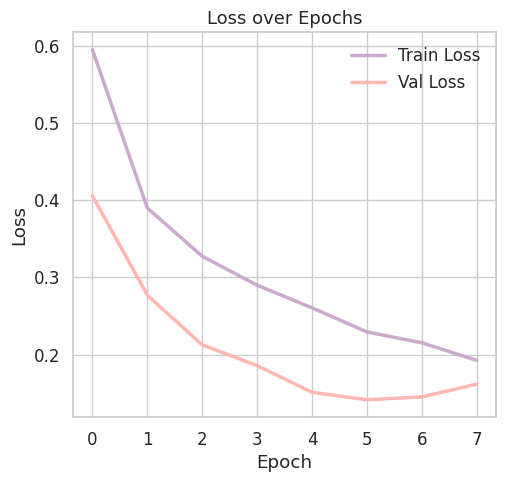

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', font_scale=1.1)
palette = ['#CBAACB', '#FFB7B2', '#FFDAC1', '#E2F0CB', '#B5EAD7']

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color=palette[0], linewidth=2.5)
plt.plot(history.history['val_loss'], label='Val Loss', color=palette[1], linewidth=2.5)
plt.title('Loss over Epochs', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(frameon=False)



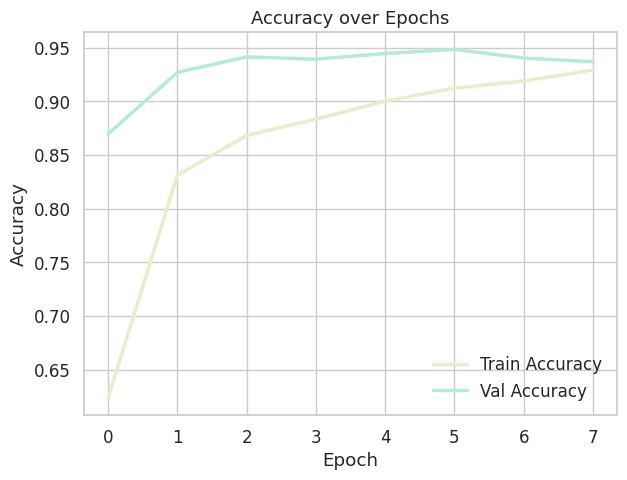

In [38]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color=palette[3], linewidth=2.5)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color=palette[4], linewidth=2.5)
plt.title('Accuracy over Epochs', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [39]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score, precision_recall_fscore_support
from tensorflow.keras import layers, Model

def make_encoder(seq_len, vocab_size, embedding_dim=128):
    inp = layers.Input(shape=(seq_len,), dtype='int32')
    x = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True)(inp)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2))(x)
    x = layers.Bidirectional(layers.LSTM(32, dropout=0.2))(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    return Model(inp, x)

def abs_diff(tensors):
    return tf.abs(tensors[0] - tensors[1])


In [40]:

seq_len = x1_val.shape[1]
vocab_size = int(np.max(np.concatenate([x1_val, x2_val]))) + 1
encoder = make_encoder(seq_len, vocab_size)

a_in = layers.Input(shape=(seq_len,), dtype='int32')
b_in = layers.Input(shape=(seq_len,), dtype='int32')

a_vec = encoder(a_in)
b_vec = encoder(b_in)

diff = layers.Lambda(abs_diff)([a_vec, b_vec])
merged = layers.Dense(64, activation='relu')(diff)
merged = layers.Dropout(0.3)(merged)
out = layers.Dense(1, activation='sigmoid')(merged)

siamese_model = Model([a_in, b_in], out)
siamese_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

siamese_model.load_weights('/content/best_siamese.h5')

y_prob = siamese_model.predict((x1_val, x2_val), batch_size=64).ravel()
y_pred_bilstm = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_val, y_pred_bilstm)
prec, rec, f1, _ = precision_recall_fscore_support(y_val, y_pred_bilstm, average='binary', zero_division=0)
auc = roc_auc_score(y_val, y_prob)

print(f'accuracy: {acc:.4f}')
print(f'precision: {prec:.4f}')
print(f'recall: {rec:.4f}')
print(f'f1: {f1:.4f}')
print(f'roc_auc: {auc:.4f}')



45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step
accuracy: 0.9486
precision: 0.9068
recall: 1.0000
f1: 0.9511
roc_auc: 0.9942


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_val, y_pred_bilstm)


In [42]:
cm

array([[1274,  146],
       [   0, 1420]])

In [43]:
classification_report(y_val, y_pred_bilstm, zero_division=0)


'              precision    recall  f1-score   support\n\n           0       1.00      0.90      0.95      1420\n           1       0.91      1.00      0.95      1420\n\n    accuracy                           0.95      2840\n   macro avg       0.95      0.95      0.95      2840\nweighted avg       0.95      0.95      0.95      2840\n'

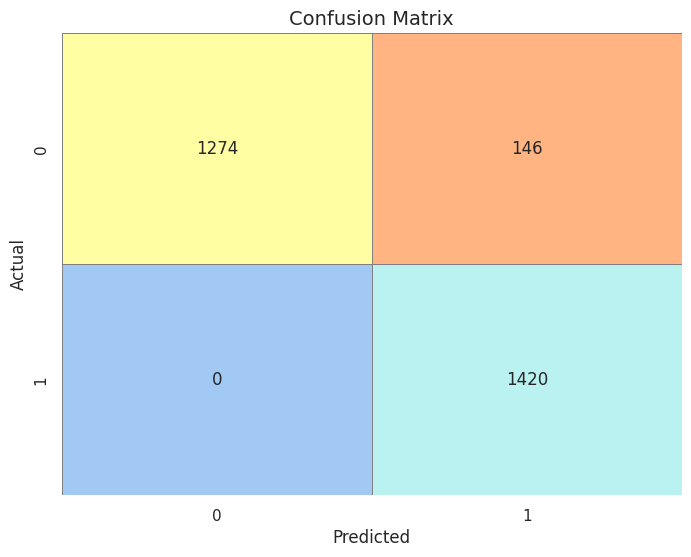

In [44]:

plt.figure(figsize=(8,6))
sns.set(style='whitegrid')
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.color_palette("pastel", as_cmap=True),
            cbar=False, linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix', fontsize=14)
plt.show()


In [45]:
import pandas as pd
import numpy as np

results = pd.DataFrame({
    'clause_a': [' '.join(map(str, seq)) for seq in x1_val],
    'clause_b': [' '.join(map(str, seq)) for seq in x2_val],
    'true_label': y_val,
    'predicted_label': y_pred_bilstm,
    'probability': y_prob
})

results['is_correct'] = results['true_label'] == results['predicted_label']

correct = results[results['is_correct']].sample(10, random_state=42)
wrong = results[~results['is_correct']].sample(10, random_state=42)


In [46]:
correct_df = correct.copy()
correct_df['clause_a'] = correct_df['clause_a'].str.slice(0, 100) + '...'
correct_df['clause_b'] = correct_df['clause_b'].str.slice(0, 100) + '...'

display(correct_df[['clause_a', 'clause_b', 'true_label', 'predicted_label', 'probability']])


,clause_a,clause_b,true_label,predicted_label,probability
2406,72 3 14 18 10 23 370 7 48 233 44 4 124 3 2 21 ...,50 2 40 47 11 286 5 373 8 2 20 143 50 246 2 50...,0,0,0.008706
2342,64 40 47 11 88 33 66 5 64 15 9 105 4 105 23 17...,64 2 40 10 11 88 5 135 6 1547 64 8 33 177 66 8...,1,1,0.960141
387,31 54 2 168 287 8 37 8199 35 7 785 12 55 17 68...,82 9 82 12 159 21 3 7 3 2 41 6 119 3 14 18 8 7...,0,0,0.004127
559,46 55 10 108 2 169 46 15 2 987 3288 0 0 0 0 0 ...,107 146 99 17 69 5 2 38 3 293 8 2 53 159 21 22...,0,0,0.004939
2556,243 36 14 18 6 33 48 528 100 10 11 224 5 11 9 ...,83 210 10 439 32 24 29 89 2 41 157 6 7 3839 10...,0,0,0.000523
1566,56 7 56 4 109 15 2 38 3 293 8 398 3 2798 967 3...,56 2 409 420 2 67 4 7 3 137 101 4 6186 10 1124...,1,1,0.915707
1190,46 8 940 3 14 87 55 2101 6 151 5 108 68 2 703 ...,46 9 55 10 108 5 68 89 2 41 3 14 87 9 278 517 ...,1,1,0.953916
1991,56 7 56 65 7 67 4 7 1070 1525 4 252 65 7 3 19 ...,56 2 592 3 7 320 56 309 1525 1070 2806 4 16 44...,1,1,0.934874
2067,46 2 46 77 15 2 868 87 41 22 46 10 584 551 7 1...,46 7 261 102 3052 12 2 55 5 2 68 8 147 17 2 18...,1,1,0.921372
2418,103 3 132 15 2 213 3 1269 229 2 74 6 848 2 48 ...,103 3 132 210 122 436 559 254 9 19 132 15 2 21...,1,1,0.954166


In [47]:
wrong_df = wrong.copy()
wrong_df['clause_a'] = wrong_df['clause_a'].str.slice(0, 100) + '...'
wrong_df['clause_b'] = wrong_df['clause_b'].str.slice(0, 100) + '...'

display(wrong_df[['clause_a', 'clause_b', 'true_label', 'predicted_label', 'probability']])


,clause_a,clause_b,true_label,predicted_label,probability
856,46 2 659 46 15 2 579 87 41 10 11 102 8 278 483...,274 17 69 5 1302 31 27 59 979 8 9 468 207 30 1...,0,1,0.858384
2010,253 3157 19 22 353 25 138 10 11 52 494 1588 67...,38 1974 57 355 3 2 278 207 3 196 3 1859 162 16...,0,1,0.672609
610,83 405 47 23 11 92 9 9 231 3 2510 2 120 5 11 1...,82 7 82 4 226 43 20 17 69 5 7 41 4 74 3 14 18 ...,0,1,0.947408
424,38 658 10 108 6 288 10 1018 9 130 6 621 38 15 ...,186 5177 26 2 344 3 39 53 3 78 6 32 7 29 465 5...,0,1,0.985202
782,107 146 8 2 53 25 159 21 22 506 2026 4 2969 11...,243 36 14 18 33 48 6 33 48 255 528 100 10 11 2...,0,1,0.715377
2312,156 16 84 9 61 8 14 18 4 2 163 117 2 268 81 2 ...,83 2 5779 10 1117 25 2 4839 4294 341 9 814 578...,0,1,0.699983
615,276 33 1367 786 25 2 259 242 5 2 3015 2 380 85...,72 1993 14 18 10 272 17 69 5 2 196 4 141 1749 ...,0,1,0.914875
1632,253 288 553 25 19 22 39 294 702 401 6 10 498 1...,38 2 131 599 12 389 100 10 11 93 15 8 130 32 2...,0,1,0.738761
1377,38 501 10 11 93 8 95 17 37 532 497 141 26 9 32...,186 389 28 219 24 4 7 190 3 2 49 970 12 2 41 3...,0,1,0.905085
374,72 2 221 28 272 14 18 12 62 5 2 20 6 2 1058 26...,276 2 288 450 439 276 3 24 155 723 760 6 443 3...,0,1,0.893001


**Attention Based Encoder**

In [48]:

seq_len = x1_train.shape[1]
embedding_dim = 100
vocab_size = int(np.max(np.concatenate([x1_train, x2_train]))) + 1
num_classes = 2


In [50]:
from tensorflow.keras import Input
from sklearn.metrics import f1_score


In [51]:
inputs = Input(shape=(seq_len,))
x = layers.Embedding(vocab_size, embedding_dim, input_length=seq_len)(inputs)

attn_scores = layers.Dense(1, activation='tanh')(x)
attn_weights = layers.Softmax(axis=1)(attn_scores)
context = layers.Dot(axes=1)([attn_weights, x])
x = layers.Flatten()(context)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_attn = Model(inputs, outputs)
model_attn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [52]:
history_attn = model_attn.fit(
    x1_train, y_train,
    validation_data=(x1_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

y_prob_attn = model_attn.predict(x1_val, batch_size=64).ravel()
y_pred_attn = (y_prob_attn >= 0.5).astype(int)

print("accuracy:", accuracy_score(y_val, y_pred_attn))
print("f1:", f1_score(y_val, y_pred_attn, average='weighted'))
print(classification_report(y_val, y_pred_attn, zero_division=0))


Epoch 1/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4945 - loss: 0.6945 - val_accuracy: 0.4912 - val_loss: 0.6938
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4860 - loss: 0.6951 - val_accuracy: 0.4905 - val_loss: 0.6937
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4914 - loss: 0.6941 - val_accuracy: 0.5056 - val_loss: 0.6934
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4988 - loss: 0.6934 - val_accuracy: 0.4930 - val_loss: 0.6934
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5025 - loss: 0.6932 - val_accuracy: 0.4894 - val_loss: 0.6936
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4970 - loss: 0.6935 - val_accuracy: 0.4887 - val_loss: 0.6958
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
accuracy: 0.5056338028169014
f1: 0.49895049218297627
              precision    recall  f1-score   support

           0       0.50      0.62      0.56      1420
           1       0.51      

In [53]:

print("accuracy:", accuracy_score(y_val, y_pred_attn))
print("f1:", f1_score(y_val, y_pred_attn, average='weighted'))


accuracy: 0.5056338028169014
f1: 0.49895049218297627


In [54]:
classification_report(y_val, y_pred_attn, zero_division=0)

'              precision    recall  f1-score   support\n\n           0       0.50      0.62      0.56      1420\n           1       0.51      0.39      0.44      1420\n\n    accuracy                           0.51      2840\n   macro avg       0.51      0.51      0.50      2840\nweighted avg       0.51      0.51      0.50      2840\n'

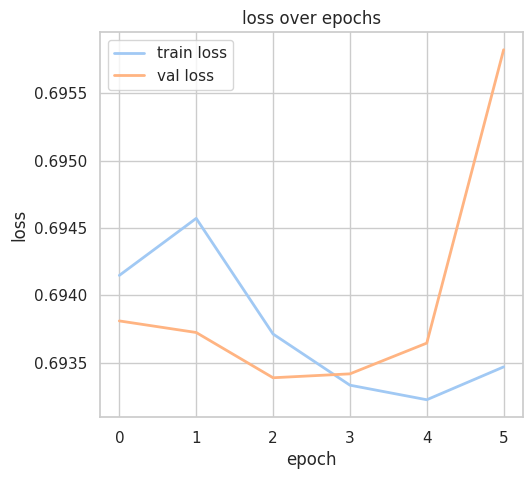

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
palette = sns.color_palette('pastel')

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_attn.history['loss'], label='train loss', color=palette[0], linewidth=2)
plt.plot(history_attn.history['val_loss'], label='val loss', color=palette[1], linewidth=2)
plt.title('loss over epochs', fontsize=12)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

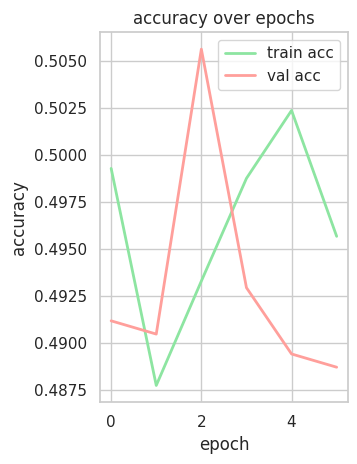

In [56]:


plt.subplot(1,2,1)
plt.plot(history_attn.history['accuracy'], label='train acc', color=palette[2], linewidth=2)
plt.plot(history_attn.history['val_accuracy'], label='val acc', color=palette[3], linewidth=2)
plt.title('accuracy over epochs', fontsize=12)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [57]:
model_attn.save('best_attn_model.keras')


In [58]:
best = tf.keras.models.load_model('best_attn_model.keras')

y_prob = best.predict(x1_val, batch_size=64).ravel()
y_pred_attn = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_val, y_pred_attn)
prec, rec, f1, _ = precision_recall_fscore_support(y_val, y_pred_attn, average='binary', zero_division=0)
auc = roc_auc_score(y_val, y_prob)


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [59]:

print(f'accuracy: {acc:.4f}')
print(f'precision: {prec:.4f}')
print(f'recall: {rec:.4f}')
print(f'f1: {f1:.4f}')
print(f'roc_auc: {auc:.4f}')


accuracy: 0.5056
precision: 0.5073
recall: 0.3901
f1: 0.4411
roc_auc: 0.5008


In [60]:

cm = confusion_matrix(y_val, y_pred_attn)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[882 538]
 [866 554]]


In [61]:
classification_report(y_val, y_pred_attn, zero_division=0)


'              precision    recall  f1-score   support\n\n           0       0.50      0.62      0.56      1420\n           1       0.51      0.39      0.44      1420\n\n    accuracy                           0.51      2840\n   macro avg       0.51      0.51      0.50      2840\nweighted avg       0.51      0.51      0.50      2840\n'

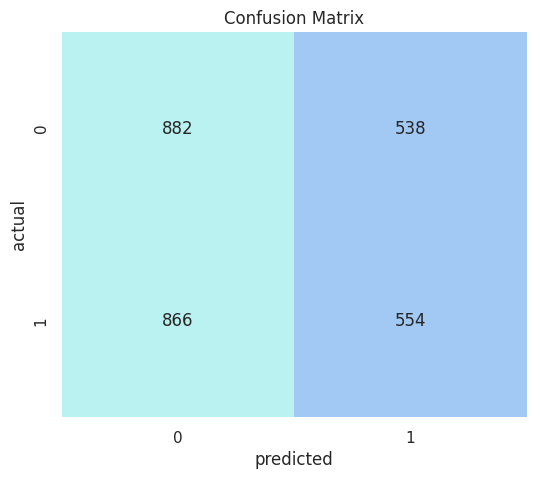

In [62]:

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.color_palette("pastel", as_cmap=True), cbar=False)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('Confusion Matrix')
plt.show()


In [63]:
idxs = np.where(y_val != y_pred_attn)[0][:10]
for idx in idxs:
    print('true', y_val[idx], 'pred', y_pred_attn[idx], 'prob', y_prob[idx])
    print('clause A:', ' '.join([str(x) for x in x1_val[idx][:50]]))
    print('clause B:', ' '.join([str(x) for x in x2_val[idx][:50]]))
    print('\n')


true 0 pred 1 prob 0.501884
clause A: 256 7 72 3 14 18 10 23 270 370 2 2912 74 3 14 18 27 10 172 13 72 8 95 17 137 41 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
clause B: 72 14 18 10 11 128 5 72 8 2 1054 267 3 2 221 12 62 378 5 2 20 121 5 180 3 6 38 15 2 31 35 121 5 13 29 7 3 2 169 10 42 508 118 1563 2 236 51 9 3 27


true 0 pred 1 prob 0.5027468
clause A: 243 36 14 18 22 266 12 2768 36 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
clause B: 103 3 132 33 67 122 436 838 6 559 63 6 24 96 529 12 63 9 13 67 538 6 438 132 6 3147 15 2 213 61 8 14 37 63 4 63 1369 28 58 62 6 8 159 19 4 9 67 263 142 32


true 0 pred 1 prob 0.5000193
clause A: 72 14 18 28 11 328 32 7 29 121 5 2 247 29 17 69 5 37 6781 384 6782 12 140 62 12 2 1732 21 5 2 16 21 205 209 4 91 369 3 2 259 2156 8 147 17 2 513 12 2 360 3
clause B: 186 35 39 53 3 78 17 69 5 31 3 7 291 32 2 29 194 16 84 39 53 3 78 292 30 37 3156 4 428 432 6 22 357 2 167 12 140 62 5 2 20 4 2 133 3 23 325 84 719 8




In [64]:

results = pd.DataFrame({
    'clause_a': [' '.join(map(str, x[:50])) for x in x1_val],
    'clause_b': [' '.join(map(str, x[:50])) for x in x2_val],
    'true_label': y_val,
    'predicted_label': y_pred_attn,
    'probability': y_prob
})

In [65]:

results['is_correct'] = results['true_label'] == results['predicted_label']

correct = results[results['is_correct']].sample(10, random_state=42)
wrong = results[~results['is_correct']].sample(10, random_state=42)



In [66]:

print("Correctly Classified Clause Pairs:\n")
display(correct[['clause_a', 'clause_b', 'true_label', 'predicted_label', 'probability']])

Correctly Classified Clause Pairs:



,clause_a,clause_b,true_label,predicted_label,probability
1203,83 239 7657 1527 9 538 6 621 661 3 24 83 452 4...,103 3 132 35 32 2 29 3 175 2 896 826 5 621 9 9...,0,0,0.495666
1528,38 338 127 5 108 7 483 4 16 38 3 183 3 7 120 3...,34 71 99 9 125 139 26 239 9882 371 2 20 262 7 ...,0,0,0.498802
1266,38 1183 2 1151 821 450 3787 14 1151 6 10 11 93...,256 2 285 230 6 250 10 172 2 175 51 342 561 66...,0,0,0.498667
2491,274 89 2 41 6 465 2 20 151 5 427 6 341 2 40 6 ...,83 439 32 24 29 6 164 33 101 5 439 32 24 29 24...,0,0,0.486609
1825,38 128 5 456 17 2 41 6 119 3 14 553 6 85 31 36...,72 14 18 28 11 328 9 12 2 1237 226 3 2 21 228 ...,0,0,0.498289
2338,38 308 752 5 2 663 150 6 58 445 5 495 174 157 ...,56 35 138 10 11 471 65 67 4 6174 422 141 4 192...,0,0,0.486565
1546,82 2 1452 127 5 73 17 69 5 9 145 12 2 3300 433...,82 9 21 127 5 484 9 74 3 14 18 433 23 690 2 21...,1,1,0.500352
2698,56 141 4 192 56 8 39 170 49 8 398 3 2802 1295 ...,56 9 320 56 680 65 9 747 1004 22 1943 9 65 33 ...,1,1,0.500820
549,243 36 14 407 10 11 266 12 6 10 11 200 6 894 8...,243 36 14 18 10 11 266 12 6 200 1606 8 95 17 2...,1,1,0.500682
661,256 2 41 3 14 37 1777 10 172 7 72 4 297 3 14 8...,256 7 74 3 14 18 27 4159 86 4 2 1166 3 44 91 2...,1,1,0.502220


In [67]:
print("\nWrongly Classified Clause Pairs:\n")
display(wrong[['clause_a', 'clause_b', 'true_label', 'predicted_label', 'probability']])


Wrongly Classified Clause Pairs:



,clause_a,clause_b,true_label,predicted_label,probability
2130,218 138 22 52 70 203 269 4 111 184 65 4 5 2 20...,218 99 9 448 8 2 239 138 22 52 116 203 218 111...,1,0,0.498248
947,276 501 786 25 9 9 1034 3 19 1346 17 2 20 19 2...,276 2 220 63 33 16 63 6 33 104 10 341 24 1316 ...,1,0,0.488637
1288,56 7 56 4 56 59 506 65 7 67 15 39 170 49 8 398...,56 9 56 4 56 15 2 38 3 293 8 39 49 435 4 8 2 1...,1,0,0.499288
1296,82 7 82 12 159 21 3 7 145 3 7 41 4 119 8 14 18...,82 1479 7 62 3 2 29 406 4 213 3 7 264 3 268 16...,1,0,0.499900
1894,186 32 2 275 3 2 641 6 58 217 4 62 24 183 6 7 ...,186 148 57 7 186 3 2 1067 3 7 120 115 5 37 231...,1,0,0.499620
649,253 9421 2 41 6 119 3 14 18 47 11 510 5 34 167...,64 570 39 34 22 548 64 115 5 372 3552 2 143 64...,0,1,0.501074
2335,243 36 14 18 47 11 266 12 6 200 8 95 17 2 796 ...,34 71 9 9 1475 2354 34 389 47 11 286 5 373 8 2...,0,1,0.500059
174,274 5 2 114 63 22 23 1281 6 364 12 67 33 104 4...,274 2 67 151 5 427 6 341 565 33 3 2 220 63 2 7...,1,0,0.498296
121,186 57 2 344 6 1090 3 7 53 3 78 379 30 1146 24...,186 2 44 10 32 104 275 265 148 77 6 102 6 2 44...,1,0,0.496790
1470,83 8 16 84 118 83 5 7617 441 136 83 5 1549 803...,83 2 501 81 6 47 439 6 623 8 130 107 6 80 89 2...,1,0,0.498490


**Comparison**

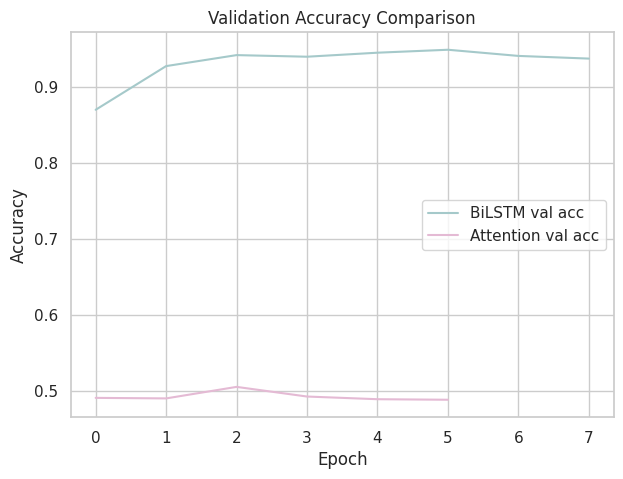

In [68]:
plt.figure(figsize=(7,5))
plt.plot(history.history['val_accuracy'], label='BiLSTM val acc', color='#a5c9ca')
plt.plot(history_attn.history['val_accuracy'], label='Attention val acc', color='#e4bad4')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [74]:

acc_bilstm = accuracy_score(y_val, y_pred_bilstm)
prec_bilstm, rec_bilstm, f1_bilstm, _ = precision_recall_fscore_support(
    y_val, y_pred_bilstm, average='binary', zero_division=0
)
auc_bilstm = roc_auc_score(y_val, y_prob)

acc_attn = accuracy_score(y_val, y_pred_attn)
prec_attn, rec_attn, f1_attn, _ = precision_recall_fscore_support(
    y_val, y_pred_attn, average='binary', zero_division=0
)
auc_attn = roc_auc_score(y_val, y_prob_attn)




In [75]:

comparison_df = pd.DataFrame({
    "Model": ["BiLSTM", "Attention"],
    "Accuracy": [acc_bilstm, acc_attn],
    "Precision": [prec_bilstm, prec_attn],
    "Recall": [rec_bilstm, rec_attn],
    "F1-Score": [f1_bilstm, f1_attn],
    "ROC-AUC": [auc_bilstm, auc_attn]
})

comparison_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,BiLSTM,0.948592,0.906769,1.000000,0.951105,0.5008
1,Attention,0.505634,0.507326,0.390141,0.441083,0.5008
